# Mini Project 1

### 1. Load 
I am learning Japanese and wanted to compare a modern, lighter anime novelization with a classical one. 

"Your Name" by Makoto Shinkai is a novelization of a 2016 anime movie.

"Confessions of a Mask" by Yukio Mishima is a classic novel published in 1949.

In [20]:
with open("kimi_no_na_wa.txt", "r", encoding="utf-8") as f:
    shinkai_text = f.read()

with open("kamen_no_kokuhaku.txt", "r", encoding="utf-8") as f:
    mishima_text = f.read()

print("Shinkai (Your Name) characters:", len(shinkai_text))
print("Mishima (Confessions of a Mask) characters:", len(mishima_text))

Shinkai (Your Name) characters: 98607
Mishima (Confessions of a Mask) characters: 148477


### 2. Tokenize

This was a major roadblock and I had to work with AI to plan this out. The lists of stop words and character names were AI generated to save time.

In [21]:
import re
from collections import Counter

def get_words(text):
    kanji_words = re.findall(r'[一-鿿]{2,}', text)
    katakana_words = re.findall(r'[゠-ヿ]{2,}', text)
    return kanji_words + katakana_words

shinkai_raw_words = get_words(shinkai_text)
mishima_raw_words = get_words(mishima_text)

# Disclaimer: this list is AI generated. I am learning japanese and this checks out, although there are a couple words I didn't know
base_stop_words = {
    '自分', '今日', '昨日', '明日', '一人', '二人', '最初', '最後', '以前', '最近',
    '本当', '全体', '一方', '場合', '理由', '程度', '今度', '何処', '何度', '何事',
    '私達', '彼ら', 'お前', '連中', '先生', '名前', '気持', '父親', '母親', '子供',
    '一緒', '周囲', '人間', '彼女', '学校', '注解', '新潮社刊', '刊行'
}

character_names = {
    '三葉', '四葉', 'サヤ', 'テッシー', 'テシガワラ', '奥寺先輩', '奥寺', '勅使河原',
    '早耶香', '滝', '瀧', '司', '高木', '俊樹', '二葉', '一葉',
    '園子', '近江', '草野', '杉子', '恒雄', '武三', '真壁', '三島由紀夫', '新海誠'
}

all_stop_words = set(base_stop_words)
for name in character_names:
    all_stop_words.add(name)

shinkai_clean_words = []
for w in shinkai_raw_words:
    if w not in all_stop_words:
        shinkai_clean_words.append(w)

mishima_clean_words = []
for w in mishima_raw_words:
    if w not in all_stop_words:
        mishima_clean_words.append(w)

shinkai_counts = Counter(shinkai_clean_words)
mishima_counts = Counter(mishima_clean_words)

print("Shinkai total filtered words:", len(shinkai_clean_words), "(unique words:", len(shinkai_counts), ")")
print("Mishima total filtered words:", len(mishima_clean_words), "(unique words:", len(mishima_counts), ")")

Shinkai total filtered words: 6259 (unique words: 2802 )
Mishima total filtered words: 13176 (unique words: 6316 )


### 3. Top 15 Frequent Words with English Translations

In [22]:
translations = {
    '先輩': 'Senpai', #Japanese term to refer to a upperclassman, used as a suffix for name
    '彗星': 'Comet',
    '言葉': 'Words',
    '東京': 'Tokyo',
    '小説': 'Novel',
    '記憶': 'Memory',
    'スマフォ': 'Smartphone', # English loanword
    '場所': 'Place',
    '祖母': 'Grandmother',
    '映画': 'Movie',
    '電車': 'Train',
    '糸守町': 'Itomori', #Fictional setting of Your Name
    '風景': 'Landscape',
    '時間': 'Time',
    '組紐': 'Braided Cord',
    '仮面': 'Mask',
    '不安': 'Anxiety',
    '少年': 'Boy',
    '欲望': 'Desire',
    '告白': 'Confession',
    '意味': 'Meaning',
    '意識': 'Consciousness',
    '人生': 'Life',
    '戯曲': 'Play',
    '接吻': 'Kiss',
    '大人': 'Adult',
    '手紙': 'Letter'
}

top_shinkai = shinkai_counts.most_common(15)
top_mishima = mishima_counts.most_common(15)

print("Rank | Shinkai Word  | English Meaning  | Count  | Mishima Word  | English Meaning  | Count")
print("-" * 85)
for i in range(15):
    s_word, s_count = top_shinkai[i]
    m_word, m_count = top_mishima[i]
    
    s_trans = translations.get(s_word, s_word)
    m_trans = translations.get(m_word, m_word)
    
    print(f"{i + 1:<4} | {s_word:<13} | {s_trans:<16} | {s_count:<6} | {m_word:<13} | {m_trans:<16} | {m_count:<6}")

Rank | Shinkai Word  | English Meaning  | Count  | Mishima Word  | English Meaning  | Count
-------------------------------------------------------------------------------------
1    | 先輩            | Senpai           | 83     | 祖母            | Grandmother      | 53    
2    | 彗星            | Comet            | 73     | 仮面            | Mask             | 46    
3    | 言葉            | Words            | 42     | 不安            | Anxiety          | 45    
4    | 東京            | Tokyo            | 41     | 少年            | Boy              | 45    
5    | 小説            | Novel            | 40     | 欲望            | Desire           | 34    
6    | 記憶            | Memory           | 40     | 告白            | Confession       | 33    
7    | スマフォ          | Smartphone       | 37     | 意味            | Meaning          | 31    
8    | 場所            | Place            | 35     | 言葉            | Words            | 31    
9    | 祖母            | Grandmother      | 31     | 小説            | Novel      

### 4. Visuals

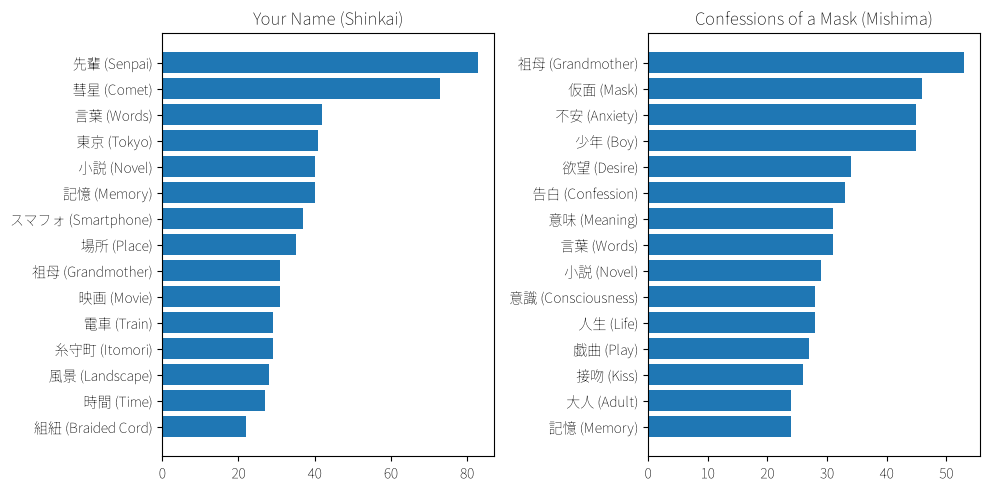

In [23]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'DejaVu Sans']
%matplotlib inline

shinkai_labels = []
shinkai_vals = []
for word, count in reversed(top_shinkai):
    meaning = translations.get(word, word)
    shinkai_labels.append(word + " (" + meaning + ")")
    shinkai_vals.append(count)

mishima_labels = []
mishima_vals = []
for word, count in reversed(top_mishima):
    meaning = translations.get(word, word)
    mishima_labels.append(word + " (" + meaning + ")")
    mishima_vals.append(count)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.barh(shinkai_labels, shinkai_vals)
ax1.set_title('Your Name (Shinkai)')

ax2.barh(mishima_labels, mishima_vals)
ax2.set_title('Confessions of a Mask (Mishima)')

plt.tight_layout()
plt.show()

### 5. Words Preferred by One Author Over the Other

In [24]:
shinkai_total = len(shinkai_clean_words)
mishima_total = len(mishima_clean_words)

shinkai_rel = {}
for word, count in shinkai_counts.items():
    shinkai_rel[word] = count / shinkai_total

mishima_rel = {}
for word, count in mishima_counts.items():
    mishima_rel[word] = count / mishima_total

all_words = set(shinkai_rel.keys()).union(set(mishima_rel.keys()))

differences = []
for word in all_words:
    freq_s = shinkai_rel.get(word, 0.0)
    freq_m = mishima_rel.get(word, 0.0)
    diff = freq_s - freq_m
    differences.append((word, diff))

differences.sort(key=lambda item: abs(item[1]), reverse=True)

print("Words with the biggest frequency differences:")
for word, diff in differences[:15]:
    meaning = translations.get(word, word)
    if diff > 0:
        favors = "Shinkai"
    else:
        favors = "Mishima"
    print(f"{word} ({meaning}): {diff:+.5f} (favors {favors})")

Words with the biggest frequency differences:
先輩 (Senpai): +0.01311 (favors Shinkai)
彗星 (Comet): +0.01166 (favors Shinkai)
スマフォ (Smartphone): +0.00591 (favors Shinkai)
東京 (Tokyo): +0.00572 (favors Shinkai)
場所 (Place): +0.00521 (favors Shinkai)
映画 (Movie): +0.00473 (favors Shinkai)
糸守町 (Itomori): +0.00463 (favors Shinkai)
記憶 (Memory): +0.00457 (favors Shinkai)
言葉 (Words): +0.00436 (favors Shinkai)
風景 (Landscape): +0.00425 (favors Shinkai)
小説 (Novel): +0.00419 (favors Shinkai)
電車 (Train): +0.00403 (favors Shinkai)
組紐 (Braided Cord): +0.00351 (favors Shinkai)
仮面 (Mask): -0.00349 (favors Mishima)
少年 (Boy): -0.00326 (favors Mishima)
